# NPTEL Course: Grid Connected Power Converters - Operating Principles

## Single-Phase H-Bridge Converter with Ideal DC Link

**Author:** V. Seshadri Sravan Kumar, IIT Hyderabad

### Objective and Modelling Scope

The goal of this simulation is to study the switched model of a single-phase H-bridge (full-bridge) converter interfaced with the grid. This notebook is the H-bridge counterpart of the switching-pole study: the converter now has **two switching poles**, leg $a$ and leg $b$, and the filter is driven by the line-to-line voltage $v_{ab}(t)$ rather than by a single pole voltage.

As in the ideal switching-pole notebook, the DC link is assumed perfectly balanced and constant for all time:

$$v_{C1}(t)=v_{C2}(t)=\frac{V_{dc}}{2}.$$

Hence, DC-link dynamics are not modeled, and the system reduces to a single state variable, the filter current $i_f(t)$.

The **modelling assumptions** are:

1. Balanced ideal DC link.
2. Ideal switching devices.
3. Grid represented as a stiff sinusoidal voltage source.
4. Saturation, and higher-order parasitic effects are neglected.

### Modulation Schemes

Each leg is described by its own switching function, $q_a(t)\in\{+1,-1\}$ and $q_b(t)\in\{+1,-1\}$. Two schemes are considered:

- **Bipolar PWM:** $q_a(t)$ is generated by comparing $m(t)=M\sin(\omega_1 t+\phi)$ with the carrier $c(t)$, and the second leg is switched in complement, $q_b(t)=-q_a(t)$.
- **Unipolar PWM:** $q_a(t)$ is generated by comparing $m_a(t)=M\sin(\omega_1 t+\phi)$ with $c(t)$, and $q_b(t)$ by comparing the half-period-shifted reference $m_b(t)=m_a\!\left(t-\tfrac{T_1}{2}\right)$ with the *same* carrier. Note that $m_a(t-T_1/2)=-m_a(t)$.

### Governing Equations

The pole voltages are $v_{ao}=\frac{V_{dc}}{2}q_a(t)$ and $v_{bo}=\frac{V_{dc}}{2}q_b(t)$, so the voltage applied across the filter branch is

$$v_{ab}(t)=v_{ao}(t)-v_{bo}(t)=\frac{V_{dc}}{2}\big[q_a(t)-q_b(t)\big].$$

With bipolar PWM this takes the two values $\pm V_{dc}$; with unipolar PWM it takes the three values $\{+V_{dc},\,0,\,-V_{dc}\}$. In both cases the peak of the fundamental component is $MV_{dc}$, which is **twice** that of a single switching pole. The AC-side current dynamics are

$$L_f\frac{di_f}{dt}=v_{ab}(t)-v_g(t)-R_f i_f(t)
\qquad\Longrightarrow\qquad
\frac{di_f}{dt}=\frac{1}{L_f}\left[\frac{V_{dc}}{2}\big(q_a(t)-q_b(t)\big)-v_g(t)-R_f i_f(t)\right].$$

### What Is Studied in This Notebook

1. Generation of the two switching functions from bipolar and unipolar PWM.
2. Time-domain waveforms of $i_f(t)$ and $v_{ab}(t)$.
3. Individual switch currents $i_a^{+}$, $i_a^{-}$, $i_b^{+}$, $i_b^{-}$.
4. Rail current waveforms $i_t(t)$ and $i_b(t)$.
5. Harmonic spectrum and THD of $v_{ab}$ and $i_f$ using DFT, and the comparison between bipolar and unipolar switching.

In [1]:
# Importing required packages

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Plotting style settings (applied globally to all subsequent plots)
plt.rcParams['figure.figsize']    = (10, 5)
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
plt.rcParams['font.size']         = 10
#
plt.rcParams['axes.spines.top']   = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['xtick.top']         = True
plt.rcParams['ytick.right']       = True
plt.rcParams['xtick.direction']   = 'in'
plt.rcParams['ytick.direction']   = 'in'

### System Parameters

The parameter values below represent a single-phase grid-connected converter rated at 3 kW, connected to a 220 V, 50 Hz grid.

Because the H-bridge applies $v_{ab}$ (peak fundamental $MV_{dc}$) instead of a single pole voltage (peak fundamental $MV_{dc}/2$), the DC-link voltage required for the same AC-side operating point is **halved**. `Vdc` is therefore set to 350 V here, against 700 V in the switching-pole notebook, so that the two studies can be compared directly.

The variable `pwm_mode` selects the modulation scheme and is the main switch to experiment with in this notebook.

In [2]:
Vg_rms   = 220.0          # grid RMS voltage (V)
f1       = 50.0           # grid fundamental frequency (Hz)

Vdc      = 350.0          # DC link voltage (V), fixed and perfectly balanced

M        = 0.89           # modulation index
phi      = -3*np.pi/4     # phase of modulating signal m(t), in radians

fsw      = 4000.0         # switching frequency (Hz)
m_f      = fsw/f1         # carrier ratio

L        = 45e-3          # filter inductance (H)
R        = 0.15           # filter resistance (ohm)

pwm_mode = 'unipolar'     # modulation scheme: 'bipolar' or 'unipolar'

### Time Discretization

The sampling interval is chosen from the required number of points per switching period. A sufficient number of samples per switching cycle helps capture ripple clearly and accurately.

In [3]:
n_cycles      = 4                             # number of fundamental cycles to simulate
n_pts_per_Tsw = 40                            # number of time instants per switching cycle

t_end         = n_cycles/f1                   # total simulation time (s)
t_step        = (1.0/fsw)/n_pts_per_Tsw       # time step (s)

t             = np.arange(0, t_end, t_step)   # time vector

### Switching Functions and Grid Voltage

The two modulating signals, the triangular carrier, and the sawtooth carrier are defined using `m_a_signal(t)`, `m_b_signal(t)`, `carrier_triangle(t)`, and `carrier_sawtooth(t)`, respectively.

In `carrier(t)`, choose the PWM carrier by commenting/uncommenting the appropriate line (sine-triangle PWM or sine-sawtooth PWM).

The leg switching functions are `qa_signal(t)` and `qb_signal(t)`. For bipolar PWM, leg $b$ is switched as the exact complement of leg $a$, $q_b=-q_a$. For unipolar PWM, leg $b$ has its own comparison against the half-period-shifted reference $m_b(t)=m_a(t-T_1/2)$.

The grid voltage is defined by `vg_signal(t)`, with grid phase set to 0.

In [4]:
def carrier_triangle(t):
    """Symmetric triangular carrier, amplitude [-1, +1], period 1/fsw."""
    Tsw = 1.0/fsw
    x = (t % Tsw)/Tsw
    return np.where(x < 0.5, 4*x - 1.0, 3.0 - 4*x)

def carrier_sawtooth(t):
    """Sawtooth carrier, amplitude [-1, +1], period 1/fsw."""
    Tsw = 1.0/fsw
    x = (t % Tsw)/Tsw
    return 2*x - 1.0

def carrier(t):
    """Carrier used by the modulator. Choose by comment/uncomment."""
    # return carrier_triangle(t)
    return carrier_sawtooth(t)

def m_a_signal(t):
    """Modulating reference for leg a."""
    return M*np.sin(2*np.pi*f1*t + phi)

def m_b_signal(t):
    """Modulating reference for leg b: m_a(t - T1/2), i.e. -m_a(t)."""
    return m_a_signal(t - 0.5/f1)

def qa_signal(t):
    """Switching function of leg a, q_a(t) in {+1, -1}."""
    return np.where(m_a_signal(t) >= carrier(t), 1.0, -1.0)

def qb_signal(t):
    """Switching function of leg b, q_b(t) in {+1, -1}."""
    if pwm_mode == 'bipolar':
        return -qa_signal(t)
    elif pwm_mode == 'unipolar':
        return np.where(m_b_signal(t) >= carrier(t), 1.0, -1.0)
    else:
        raise ValueError("pwm_mode must be 'bipolar' or 'unipolar'")

def vg_signal(t):
    """Grid voltage."""
    return np.sqrt(2)*Vg_rms*np.cos(2*np.pi*f1*t)

### Visualization of the Switching Functions

The code below plots the two modulating signals against the carrier, the individual leg switching functions $q_a(t)$ and $q_b(t)$, and their difference $q_a(t)-q_b(t)$, over one fundamental cycle and over four switching cycles.

The bottom row is the important one: $q_a-q_b$ is the normalized shape of $v_{ab}$. It takes only the values $\pm2$ under bipolar PWM, and $\{+2,0,-2\}$ under unipolar PWM.

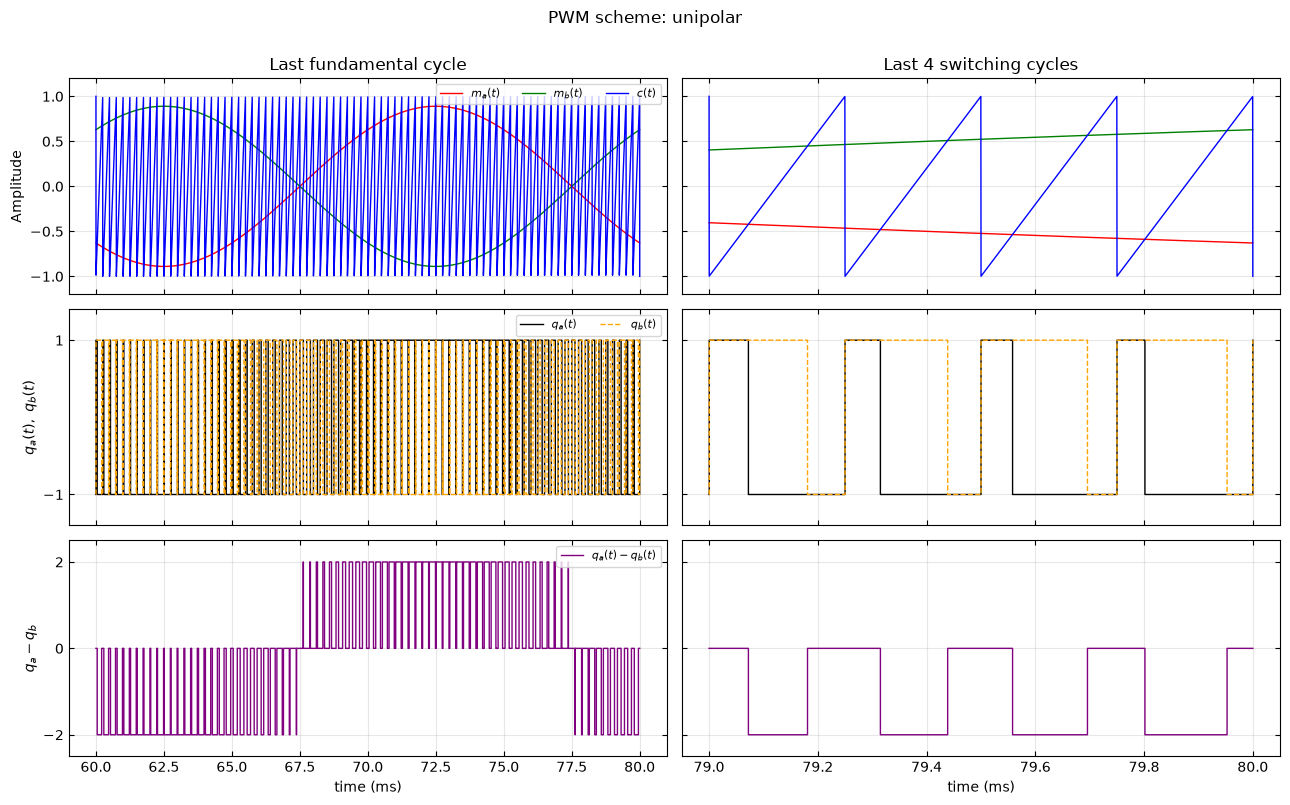

In [5]:
T1  = 1.0/f1
Tsw = 1.0/fsw

# Last 1 fundamental cycle
t_fund  = np.linspace(t_end - T1, t_end, 12000)
ma_fund = m_a_signal(t_fund)
mb_fund = m_b_signal(t_fund)
c_fund  = carrier(t_fund)
qa_fund = qa_signal(t_fund)
qb_fund = qb_signal(t_fund)

# Last 4 switching cycles
t_zoom  = np.linspace(t_end - 4*Tsw, t_end, 3000)
ma_zoom = m_a_signal(t_zoom)
mb_zoom = m_b_signal(t_zoom)
c_zoom  = carrier(t_zoom)
qa_zoom = qa_signal(t_zoom)
qb_zoom = qb_signal(t_zoom)

fig, axs = plt.subplots(3, 2, figsize=(13, 8), sharex='col', sharey='row')

# Row 1: modulating signals and carrier
axs[0, 0].plot(t_fund*1000, ma_fund, color='red',   lw=1.0, label='$m_a(t)$')
axs[0, 0].plot(t_fund*1000, mb_fund, color='green', lw=1.0, label='$m_b(t)$')
axs[0, 0].plot(t_fund*1000, c_fund,  color='blue',  lw=1.0, label='$c(t)$')
axs[0, 0].set_title('Last fundamental cycle')
axs[0, 0].set_ylabel('Amplitude')
axs[0, 0].set_ylim([-1.2, 1.2])
axs[0, 0].legend(loc='upper right', ncol=3, fontsize=8)

axs[0, 1].plot(t_zoom*1000, ma_zoom, color='red',   lw=1.0)
axs[0, 1].plot(t_zoom*1000, mb_zoom, color='green', lw=1.0)
axs[0, 1].plot(t_zoom*1000, c_zoom,  color='blue',  lw=1.0)
axs[0, 1].set_title('Last 4 switching cycles')
axs[0, 1].set_ylim([-1.2, 1.2])

# Row 2: leg switching functions
axs[1, 0].step(t_fund*1000, qa_fund, where='post', color='black',  lw=1.0, label='$q_a(t)$')
axs[1, 0].step(t_fund*1000, qb_fund, where='post', color='orange', lw=1.0, ls='--', label='$q_b(t)$')
axs[1, 0].set_ylabel('$q_a(t),\\ q_b(t)$')
axs[1, 0].set_yticks([-1, 1])
axs[1, 0].set_ylim([-1.4, 1.4])
axs[1, 0].legend(loc='upper right', ncol=2, fontsize=8)

axs[1, 1].step(t_zoom*1000, qa_zoom, where='post', color='black',  lw=1.0)
axs[1, 1].step(t_zoom*1000, qb_zoom, where='post', color='orange', lw=1.0, ls='--')

# Row 3: difference of switching functions
axs[2, 0].step(t_fund*1000, qa_fund - qb_fund, where='post', color='purple', lw=1.0, label='$q_a(t)-q_b(t)$')
axs[2, 0].set_ylabel('$q_a-q_b$')
axs[2, 0].set_xlabel('time (ms)')
axs[2, 0].set_yticks([-2, 0, 2])
axs[2, 0].set_ylim([-2.5, 2.5])
axs[2, 0].legend(loc='upper right', fontsize=8)

axs[2, 1].step(t_zoom*1000, qa_zoom - qb_zoom, where='post', color='purple', lw=1.0)
axs[2, 1].set_xlabel('time (ms)')

fig.suptitle(f'PWM scheme: {pwm_mode}', y=1.00)
plt.tight_layout()
plt.show()

### Initial Condition Selection

Initial condition selection is important. If `i_f(0)` is set to zero, the simulation may need a longer runtime to reach steady state because `R` is small.

To reduce startup transients, `i_f(0)` is initialized from a fundamental-frequency steady-state phasor estimate. The only change with respect to the switching-pole notebook is that the converter-side phasor is now $V_{ab}=MV_{dc}\angle(\phi-\pi/2)$ instead of $MV_{dc}/2$.

In [6]:
w1          = 2*np.pi*f1

V_ab_phasor = (Vdc*M) * np.exp(1j*(phi - np.pi/2))
V_g_phasor  = np.sqrt(2)*Vg_rms * np.exp(1j*0)

I_f_phasor  = (V_ab_phasor - V_g_phasor) / (R + 1j*w1*L)

x0          = np.array([np.real(I_f_phasor)])

print(f"The initial current through the inductor is i_f(0) = {x0[0]:.3f} A")

The initial current through the inductor is i_f(0) = 15.180 A


### ODE Formulation and Numerical Integration

The state equation contains a single state, $i_f(t)$. Numerical integration is carried out using `solve_ivp`, with `max_step` limited to the chosen simulation step so that switching transitions are properly captured.

In [7]:
def rhs(t, x):
    i_f  = x[0]
    qa   = qa_signal(t)
    qb   = qb_signal(t)
    vg   = vg_signal(t)
    v_ab = Vdc/2*(qa - qb)
    di_f = (v_ab - R*i_f - vg)/L
    return np.array([di_f])

max_step = t_step
sol      = solve_ivp(rhs, (t[0], t[-1]), x0, max_step=max_step, dense_output=True)

i_f = sol.sol(t)[0]

### Waveforms: Injected Current and Converter Output Voltage

The two primary signals, $i_f(t)$ and $v_{ab}(t)$, are examined at three time scales: full simulation interval, final two fundamental cycles, and final four switching cycles.

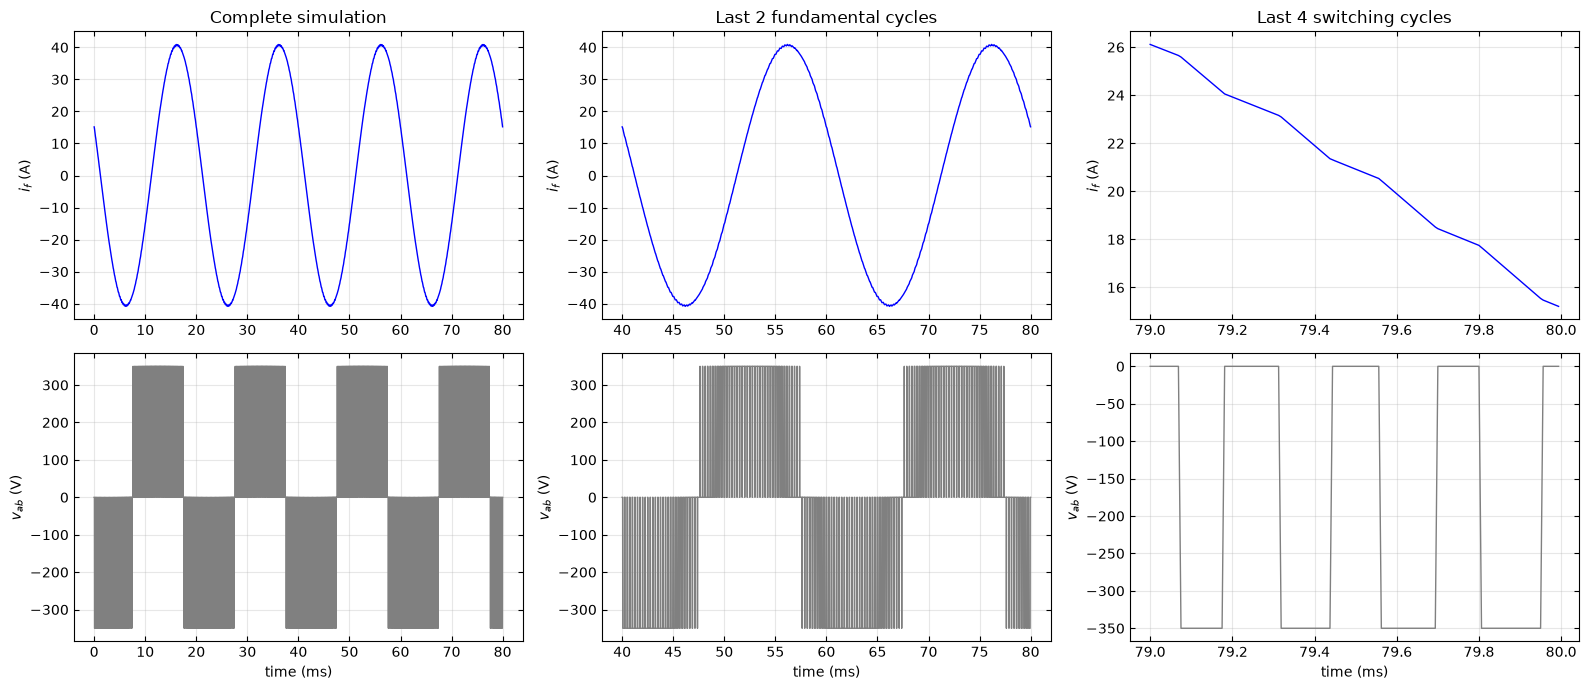

In [8]:
qa_t = qa_signal(t)
qb_t = qb_signal(t)
v_ab = Vdc/2 * (qa_t - qb_t)

# Time windows
mask_1fund = (t >= (t_end - 1/f1))
mask_2fund = (t >= (t_end - 2/f1))
mask_4sw   = (t >= (t_end - 4/fsw))

fig, axs = plt.subplots(2, 3, figsize=(16, 7))

# -------------------------------
# Top row: injected current i_f(t)
# -------------------------------
axs[0, 0].plot(t*1000, i_f, color='blue', lw=1.0)
axs[0, 0].set_title('Complete simulation')
axs[0, 0].set_ylabel('$i_f$ (A)')

axs[0, 1].plot(t[mask_2fund]*1000, i_f[mask_2fund], color='blue', lw=1.0)
axs[0, 1].set_title('Last 2 fundamental cycles')
axs[0, 1].set_ylabel('$i_f$ (A)')

axs[0, 2].plot(t[mask_4sw]*1000, i_f[mask_4sw], color='blue', lw=1.0)
axs[0, 2].set_title('Last 4 switching cycles')
axs[0, 2].set_ylabel('$i_f$ (A)')

# ---------------------------------------
# Bottom row: converter voltage v_ab(t)
# ---------------------------------------
axs[1, 0].plot(t*1000, v_ab, color='gray', lw=1.0)
axs[1, 0].set_ylabel('$v_{ab}$ (V)')
axs[1, 0].set_xlabel('time (ms)')

axs[1, 1].plot(t[mask_2fund]*1000, v_ab[mask_2fund], color='gray', lw=1.0)
axs[1, 1].set_ylabel('$v_{ab}$ (V)')
axs[1, 1].set_xlabel('time (ms)')

axs[1, 2].plot(t[mask_4sw]*1000, v_ab[mask_4sw], color='gray', lw=1.0)
axs[1, 2].set_ylabel('$v_{ab}$ (V)')
axs[1, 2].set_xlabel('time (ms)')

plt.tight_layout()
plt.show()

### Switch Currents

Each leg has a top and a bottom switch. Following the tutorial derivation, the individual switch currents are

$$i_a^{+}(t)=\left(\frac{1+q_a(t)}{2}\right)i_f(t),\qquad
i_a^{-}(t)=-\left(\frac{1-q_a(t)}{2}\right)i_f(t),$$

$$i_b^{+}(t)=-\left(\frac{1+q_b(t)}{2}\right)i_f(t),\qquad
i_b^{-}(t)=\left(\frac{1-q_b(t)}{2}\right)i_f(t).$$

The sign difference between the two legs arises because the filter current leaves node $a$ and returns into node $b$.

The four switching combinations $(q_a,q_b)$ and the resulting switch and rail currents are printed below as a check against the table derived in the tutorial.

In [9]:
# ------------------------------------------------------------
# Switch-current table for the four switching combinations
# ------------------------------------------------------------

def label(coeff):
    """Return the switch current as a multiple of i_f, in readable form."""
    if np.isclose(coeff,  0.0): return '0'
    if np.isclose(coeff,  1.0): return 'i_f'
    if np.isclose(coeff, -1.0): return '-i_f'
    return f'{coeff:+.1f} i_f'

hdr = ['(q_a, q_b)', 'i_a+', 'i_a-', 'i_b+', 'i_b-', 'i_t', 'i_b (rail)']
print(''.join(f'{h:>13s}' for h in hdr))

for qa_v in (-1.0, 1.0):
    for qb_v in (-1.0, 1.0):
        ia_p = (1 + qa_v)/2
        ia_m = -(1 - qa_v)/2
        ib_p = -(1 + qb_v)/2
        ib_m = (1 - qb_v)/2
        i_t_c = ia_p + ib_p          # top rail
        i_b_c = ia_m + ib_m          # bottom rail
        row = [f'({qa_v:+.0f}, {qb_v:+.0f})',
               label(ia_p), label(ia_m), label(ib_p), label(ib_m),
               label(i_t_c), label(i_b_c)]
        print(''.join(f'{c:>13s}' for c in row))

   (q_a, q_b)         i_a+         i_a-         i_b+         i_b-          i_t   i_b (rail)
     (-1, -1)            0         -i_f            0          i_f            0            0
     (-1, +1)            0         -i_f         -i_f            0         -i_f         -i_f
     (+1, -1)          i_f            0            0          i_f          i_f          i_f
     (+1, +1)          i_f            0         -i_f            0            0            0


The switch currents are now evaluated along the simulated trajectory and plotted over the last two fundamental cycles. Each device conducts only over the intervals defined by its own switching function, and the four waveforms together reconstruct $i_f(t)$ at every instant.

Note that each waveform takes both signs. A switching function here describes an ideal bidirectional switch, that is, a controlled device together with its antiparallel diode. Intervals where the plotted current is positive correspond to conduction through the controlled device, and intervals where it is negative correspond to conduction through the antiparallel diode. Separating the two would require a device-level model, which is beyond the scope of this study.

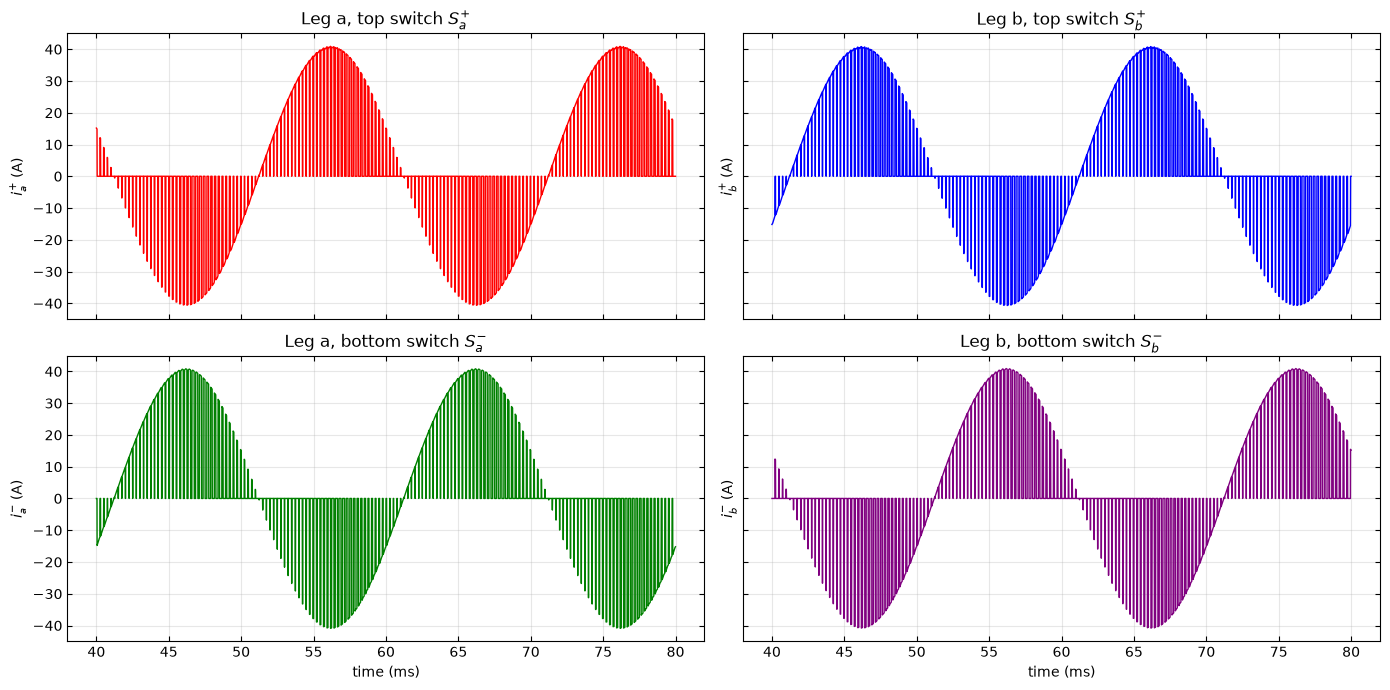

In [10]:
i_ap = (1 + qa_t)/2 * i_f
i_am = -(1 - qa_t)/2 * i_f
i_bp = -(1 + qb_t)/2 * i_f
i_bm = (1 - qb_t)/2 * i_f

fig, axs = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)

axs[0, 0].plot(t[mask_2fund]*1000, i_ap[mask_2fund], color='red', lw=1.0)
axs[0, 0].set_ylabel('$i_a^{+}$ (A)')
axs[0, 0].set_title('Leg a, top switch $S_a^{+}$')

axs[0, 1].plot(t[mask_2fund]*1000, i_bp[mask_2fund], color='blue', lw=1.0)
axs[0, 1].set_ylabel('$i_b^{+}$ (A)')
axs[0, 1].set_title('Leg b, top switch $S_b^{+}$')

axs[1, 0].plot(t[mask_2fund]*1000, i_am[mask_2fund], color='green', lw=1.0)
axs[1, 0].set_ylabel('$i_a^{-}$ (A)')
axs[1, 0].set_xlabel('time (ms)')
axs[1, 0].set_title('Leg a, bottom switch $S_a^{-}$')

axs[1, 1].plot(t[mask_2fund]*1000, i_bm[mask_2fund], color='purple', lw=1.0)
axs[1, 1].set_ylabel('$i_b^{-}$ (A)')
axs[1, 1].set_xlabel('time (ms)')
axs[1, 1].set_title('Leg b, bottom switch $S_b^{-}$')

plt.tight_layout()
plt.show()

### Rail Current Waveforms

Summing the switch currents of the two legs gives the rail currents

$$i_t(t)=i_a^{+}(t)+i_b^{+}(t)=\frac{q_a(t)-q_b(t)}{2}\,i_f(t),\qquad
i_b(t)=i_a^{-}(t)+i_b^{-}(t)=\frac{q_a(t)-q_b(t)}{2}\,i_f(t).$$

An important structural difference with respect to the single switching pole appears here. In the H-bridge the DC-link midpoint $o$ carries no current, so the two rail currents are **identical** at every instant, $i_t(t)=i_b(t)$. In the switching-pole converter the load current returned through the midpoint, and the two rail currents were complementary rather than equal.

Note also that $v_{ab}i_f = v_{dc}i_t$ holds instantaneously, so the model conserves power across the switching network.

Maximum |i_t - i_b| over the simulation: 0.000e+00 A
Maximum power-balance mismatch |v_ab*i_f - Vdc*i_t|: 0.000e+00 W


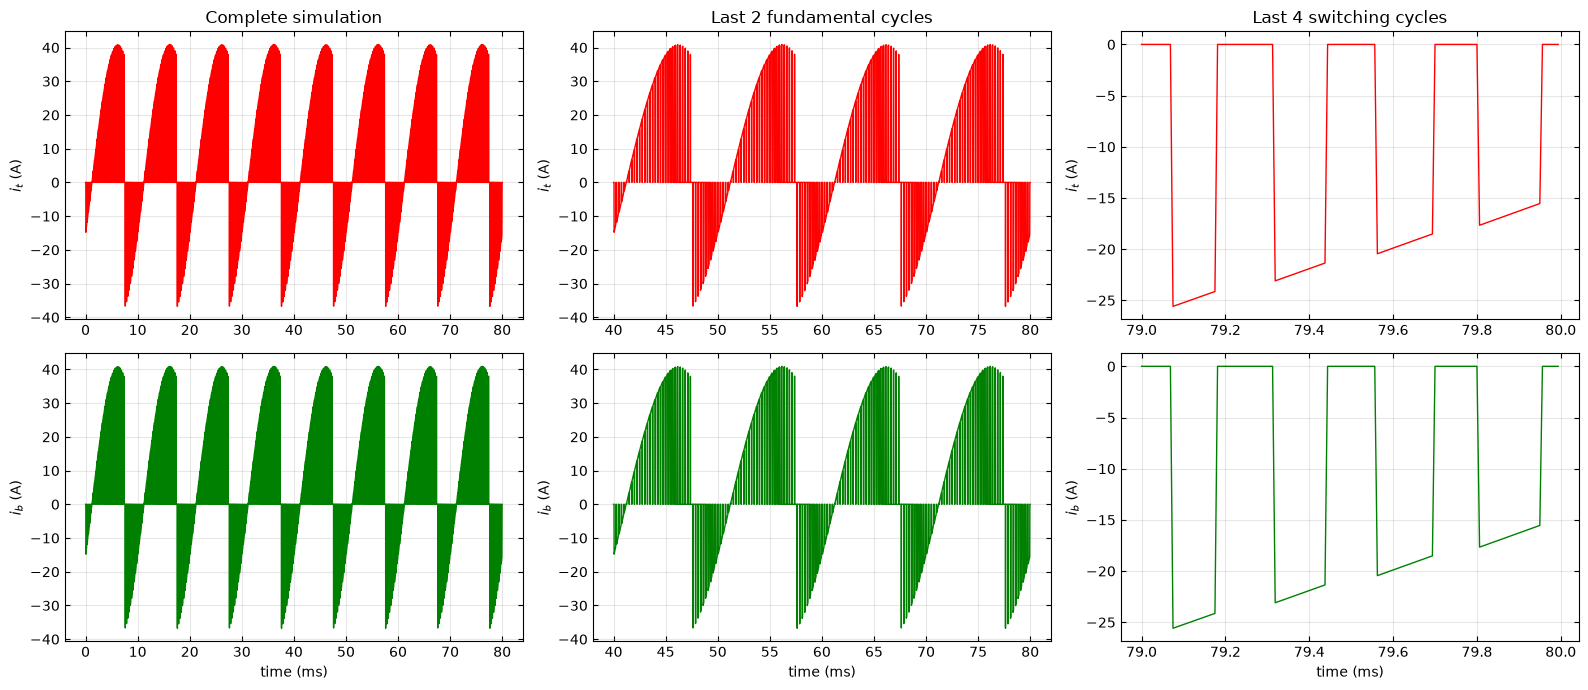

In [11]:
i_t = (qa_t - qb_t)/2 * i_f
i_b = (qa_t - qb_t)/2 * i_f

print("Maximum |i_t - i_b| over the simulation: {:.3e} A".format(np.max(np.abs(i_t - i_b))))
print("Maximum power-balance mismatch |v_ab*i_f - Vdc*i_t|: {:.3e} W".format(
    np.max(np.abs(v_ab*i_f - Vdc*i_t))))

fig, axs = plt.subplots(2, 3, figsize=(16, 7))

# -------------------------
# Top row: top rail current i_t(t)
# -------------------------
axs[0, 0].plot(t*1000, i_t, color='red', lw=1.0)
axs[0, 0].set_title('Complete simulation')
axs[0, 0].set_ylabel('$i_t$ (A)')

axs[0, 1].plot(t[mask_2fund]*1000, i_t[mask_2fund], color='red', lw=1.0)
axs[0, 1].set_title('Last 2 fundamental cycles')
axs[0, 1].set_ylabel('$i_t$ (A)')

axs[0, 2].plot(t[mask_4sw]*1000, i_t[mask_4sw], color='red', lw=1.0)
axs[0, 2].set_title('Last 4 switching cycles')
axs[0, 2].set_ylabel('$i_t$ (A)')

# ----------------------------
# Bottom row: bottom rail current i_b(t)
# ----------------------------
axs[1, 0].plot(t*1000, i_b, color='green', lw=1.0)
axs[1, 0].set_ylabel('$i_b$ (A)')
axs[1, 0].set_xlabel('time (ms)')

axs[1, 1].plot(t[mask_2fund]*1000, i_b[mask_2fund], color='green', lw=1.0)
axs[1, 1].set_ylabel('$i_b$ (A)')
axs[1, 1].set_xlabel('time (ms)')

axs[1, 2].plot(t[mask_4sw]*1000, i_b[mask_4sw], color='green', lw=1.0)
axs[1, 2].set_ylabel('$i_b$ (A)')
axs[1, 2].set_xlabel('time (ms)')

plt.tight_layout()
plt.show()

### Harmonic Analysis by Discrete Fourier Transform

For harmonic analysis, one steady-state fundamental period, $T_1=1/f_1$, is extracted from each waveform and sampled at $N$ points. The Fourier coefficients are computed using

$$C_k=\frac{1}{N}\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}.$$

Because the analysis window equals one fundamental period, the DFT bin index $k$ is directly the harmonic order $h$.

For real-valued signals, coefficients are converted to a single-sided peak-amplitude spectrum by taking $\hat C_h=2C_h$ for $h>0$, with standard treatment of the DC and Nyquist bins. Total harmonic distortion is then evaluated as

$$THD=\frac{\sqrt{\sum_{h\ge 2}|\hat C_h|^2}}{|\hat C_1|}.$$

The following code implements this procedure and plots magnitude and phase spectra versus harmonic order.

In [13]:
def dft(signal):
    """Direct DFT via the DFT matrix."""
    N = len(signal)
    k = np.arange(N)
    n = np.arange(N)
    W = (1/N) * np.exp(-2j * np.pi * np.outer(k, n) / N)
    return W @ signal

def dft_peak(signal):
    """Single-sided peak-amplitude spectrum for a real-valued signal."""
    N = len(signal)
    Ck = dft(signal)
    n_bins = N // 2 + 1
    Ck_p = (2 * Ck[:n_bins]).copy()
    Ck_p[0] /= 2
    if N % 2 == 0:
        Ck_p[-1] /= 2
    return Ck_p

def compute_thd(Ck_p):
    """Total harmonic distortion from the peak-amplitude spectrum."""
    fundamental_magnitude = np.abs(Ck_p[1])
    harmonic_magnitudes = np.abs(Ck_p[2:])
    thd = np.sqrt(np.sum(harmonic_magnitudes**2)) / fundamental_magnitude if fundamental_magnitude > 0 else 0
    print("The total harmonic distortion (THD) is {:.2f}%".format(thd * 100))
    return thd

def plot_spectrum(Ck_p, h_max=200, title=None, unit=''):
    """Plot magnitude and phase spectra side by side, vs. harmonic order h."""
    h = np.arange(len(Ck_p))
    mask = (h <= h_max)

    mag   = np.abs(Ck_p[mask])
    phase = np.degrees(np.angle(Ck_p[mask]))
    phase[mag < 1e-6*np.max(mag)] = 0.0

    fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))

    axs[0].stem(h[mask], mag, linefmt='tab:blue', markerfmt='o', basefmt=' ')
    axs[0].set_xlabel('harmonic order $h$')
    axs[0].set_ylabel(f'magnitude {unit}')
    axs[0].set_title('Magnitude spectrum' if title is None else f'{title} -- magnitude')
    axs[0].set_xlim([0, h_max])

    axs[1].stem(h[mask], phase, linefmt='tab:red', markerfmt='o', basefmt=' ')
    axs[1].set_xlabel('harmonic order $h$')
    axs[1].set_ylabel('phase (deg)')
    axs[1].set_title('Phase spectrum' if title is None else f'{title} -- phase')
    axs[1].set_xlim([0, h_max])

    plt.tight_layout()
    plt.show()

### DFT Evaluation Window

The DFT is evaluated with $N=2048$ uniformly spaced samples taken over the final fundamental cycle, which is treated as steady state.

The harmonic orders of interest lie around the carrier ratio $m_f=f_{sw}/f_1$ and its multiples, so the spectra are plotted up to $h_{max}=200$ for $m_f=80$.

PWM scheme: unipolar, carrier ratio m_f = 80

Converter voltage v_ab:
  fundamental peak = 312.17 V (theoretical M*Vdc = 311.50 V)
The total harmonic distortion (THD) is 65.49%


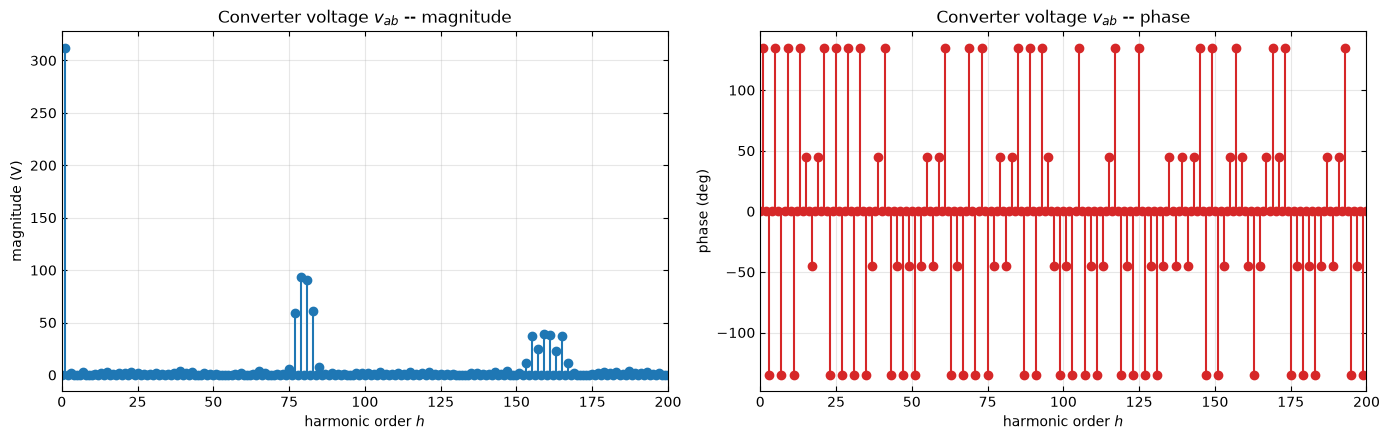


Injected current i_f:
  fundamental peak = 40.67 A
The total harmonic distortion (THD) is 0.36%


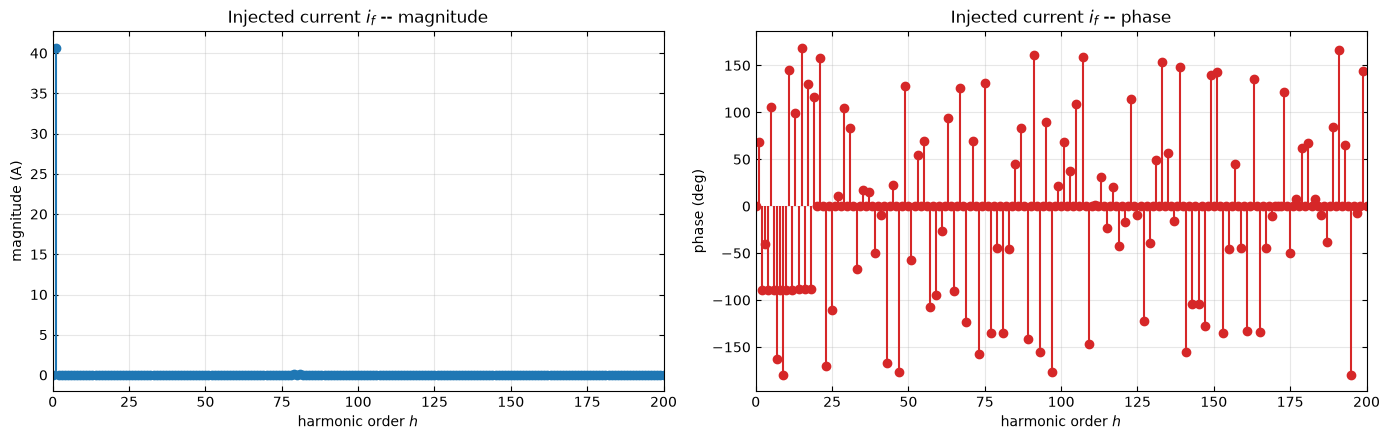

In [14]:
N_dft = 2048
t_window = np.linspace(t_end - 1/f1, t_end, N_dft, endpoint=False)

vab_window = Vdc/2 * (qa_signal(t_window) - qb_signal(t_window))
i_f_window = sol.sol(t_window)[0]

print(f"PWM scheme: {pwm_mode}, carrier ratio m_f = {m_f:.0f}")
print()

vab_Ck_p = dft_peak(vab_window)
print("Converter voltage v_ab:")
print("  fundamental peak = {:.2f} V (theoretical M*Vdc = {:.2f} V)".format(np.abs(vab_Ck_p[1]), M*Vdc))
compute_thd(vab_Ck_p)
plot_spectrum(vab_Ck_p, h_max=200, title='Converter voltage $v_{ab}$', unit='(V)')

i_f_Ck_p = dft_peak(i_f_window)
print()
print("Injected current i_f:")
print("  fundamental peak = {:.2f} A".format(np.abs(i_f_Ck_p[1])))
compute_thd(i_f_Ck_p)
plot_spectrum(i_f_Ck_p, h_max=200, title='Injected current $i_f$', unit='(A)')

### A Note on Harmonic Components

The spectra above are not spread uniformly over frequency. They are organized into **clusters (sidebands) centred on integer multiples of the carrier ratio** $m_f=f_{sw}/f_1$, that is, around $h=m_f,\,2m_f,\,3m_f,\dots$, with each cluster containing components at $h=km_f\pm n$. With $f_{sw}=4$ kHz and $f_1=50$ Hz, $m_f=80$, so the first cluster sits near the 80th harmonic.

Two consequences follow.

1. **The filter sees a well-separated spectrum.** The fundamental is at $h=1$ and the nearest significant switching component is two orders of magnitude higher in frequency. The inductive filter attenuates roughly as $1/h$, which is why the voltage THD is large while the current THD is small.
2. **The modulation scheme decides where the first cluster lies.** Under bipolar PWM, $v_{ab}$ is a two-level waveform and the dominant cluster appears at $h\approx m_f$. Under unipolar PWM with a **triangular** carrier, the components at $m_f$ cancel between the two legs, and the first significant cluster is shifted to $2m_f$. The effective switching frequency seen by the filter is doubled without increasing the device switching frequency.

The cell below evaluates both modulation schemes with both carriers and prints the resulting THD values so that this effect can be verified numerically rather than asserted. Note that the cancellation at $m_f$ is specific to the triangular carrier; with a sawtooth carrier, unipolar switching still reduces distortion, but the $m_f$ cluster is not eliminated.

In [15]:
# ------------------------------------------------------------
# Compare modulation schemes and carriers
# (this cell temporarily overrides pwm_mode and carrier)
# ------------------------------------------------------------

pwm_mode_saved = pwm_mode
carrier_saved  = carrier

results = []

for mode in ['bipolar', 'unipolar']:
    for carrier_name, carrier_fun in [('triangle', carrier_triangle),
                                      ('sawtooth', carrier_sawtooth)]:
        pwm_mode = mode
        carrier  = carrier_fun

        sol_c = solve_ivp(rhs, (t[0], t[-1]), x0, max_step=t_step, dense_output=True)

        vab_c = Vdc/2*(qa_signal(t_window) - qb_signal(t_window))
        i_f_c = sol_c.sol(t_window)[0]

        Cv = dft_peak(vab_c)
        Ci = dft_peak(i_f_c)

        thd_v = np.sqrt(np.sum(np.abs(Cv[2:])**2))/np.abs(Cv[1])
        thd_i = np.sqrt(np.sum(np.abs(Ci[2:])**2))/np.abs(Ci[1])

        # harmonic order of the largest switching-frequency component
        h_dom = int(np.argmax(np.abs(Cv[2:])) + 2)

        results.append((mode, carrier_name, np.abs(Cv[1]), thd_v*100, thd_i*100, h_dom))

pwm_mode = pwm_mode_saved
carrier  = carrier_saved

print(f"{'scheme':>10s}{'carrier':>11s}{'|V_ab1| (V)':>14s}{'THD v_ab (%)':>15s}{'THD i_f (%)':>14s}{'dominant h':>13s}")
for r in results:
    print(f"{r[0]:>10s}{r[1]:>11s}{r[2]:>14.2f}{r[3]:>15.2f}{r[4]:>14.3f}{r[5]:>13d}")

    scheme    carrier   |V_ab1| (V)   THD v_ab (%)   THD i_f (%)   dominant h
   bipolar   triangle        310.73         123.97         0.659           80
   bipolar   sawtooth        312.82         122.62         0.786           80
  unipolar   triangle        310.73          65.37         0.190          159
  unipolar   sawtooth        312.17          65.49         0.357           79


### Credits and Disclaimer

This notebook is part of the NPTEL course *Grid Connected Power Converters - Operating Principles*.

The simulation ideas, modelling approach, and technical interpretation in this notebook are original to the author.

This notebook presents an idealized H-bridge converter model. It assumes a constant balanced DC link and other simplifying idealizations that are appropriate for pedagogical study of waveforms and harmonic content. The results are therefore useful for understanding the operating principle and analysis method, but they are not a substitute for detailed converter design validation.

AI assistance was used only to polish and refine portions of the code structure and documentation language.